<center><h1>QBUS2820 Assignment 1 - Predicting Weekly Rent</h1></center>

**Student ID:** SID

This notebook contains the full analysis for Assignment 1:

1. Setup and data
2. Exploratory data analysis (EDA)
3. Modelling and model selection *(to be added)*
4. Final model and predictions *(to be added)*

`WeeklyRent_training.csv` and `WeeklyRent_test_noLabel.csv` must be in the same folder as this notebook.
Figures are saved to the `figures/` folder.

## 1. Setup and data

This notebook relies on the following imports and settings. Other packages are loaded in context,
where they are first used.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_context('notebook')
sns.set_style('ticks')

import os
os.makedirs('figures', exist_ok=True) # folder for saved figures

### Data

We load the training data (with the response) and the test covariates (without the response).
Below, we record the names of the response and predictor variables for subsequent use.

In [2]:
train = pd.read_csv('WeeklyRent_training.csv')
test = pd.read_csv('WeeklyRent_test_noLabel.csv')

response = 'WeeklyRent'
predictors = [x for x in list(train.columns) if x != response] # building a list of predictors
continuous = ['DistanceCBD', 'FloorArea', 'PropertyAge']
binary = ['NearTrain', 'Furnished', 'HighDemandArea']

train.head()

,WeeklyRent,DistanceCBD,Bedrooms,FloorArea,PropertyAge,NearTrain,Furnished,HighDemandArea
0,774.30,1.57,1,49.1,24.9,0,1,0
1,980.10,12.33,2,96.1,14.0,1,0,1
2,686.14,23.70,2,82.0,1.1,0,1,0
3,968.39,6.85,1,59.9,12.3,1,1,1
4,849.06,19.88,3,93.5,8.0,1,0,0


## 2. Exploratory data analysis

### 2.1 Structure of the data

We check the number of observations, the number of variables and the type of each variable.

In [3]:
print('Training data: {} rows, {} columns'.format(train.shape[0], train.shape[1]))
print('Test data:     {} rows, {} columns'.format(test.shape[0], test.shape[1]))
train.dtypes

Training data: 5000 rows, 8 columns
Test data:     1000 rows, 7 columns


WeeklyRent        float64
DistanceCBD       float64
Bedrooms            int64
FloorArea         float64
PropertyAge       float64
NearTrain           int64
Furnished           int64
HighDemandArea      int64
dtype: object

All variables are numerical. `DistanceCBD`, `FloorArea` and `PropertyAge` are continuous, `Bedrooms` is a count (1 to 5),
and `NearTrain`, `Furnished` and `HighDemandArea` are already coded as 0/1 dummy variables, so no further encoding is needed.

### 2.2 Missing values and duplicates

In [4]:
print('Missing values in training data: {}'.format(train.isna().sum().sum()))
print('Missing values in test data:     {}'.format(test.isna().sum().sum()))
print('Duplicated rows in training data: {}'.format(train.duplicated().sum()))

Missing values in training data: 0
Missing values in test data:     0
Duplicated rows in training data: 0


### 2.3 Summary statistics

Summary statistics of all variables in the training data, rounded to four decimal places.

In [5]:
train.describe().T.round(4)

,count,mean,std,min,25%,50%,75%,max
WeeklyRent,5000.0,860.6811,215.4138,194.26,703.075,849.090,1003.3525,1741.4
DistanceCBD,5000.0,13.5099,9.5587,0.62,5.430,11.415,20.0900,40.0
Bedrooms,5000.0,2.3628,1.0902,1.00,2.000,2.000,3.0000,5.0
FloorArea,5000.0,87.8890,30.1933,35.00,65.000,85.700,108.2250,191.2
PropertyAge,5000.0,19.7222,14.1877,0.10,9.275,16.400,26.6000,100.0
NearTrain,5000.0,0.4620,0.4986,0.00,0.000,0.000,1.0000,1.0
Furnished,5000.0,0.2998,0.4582,0.00,0.000,0.000,1.0000,1.0
HighDemandArea,5000.0,0.4562,0.4981,0.00,0.000,0.000,1.0000,1.0


### 2.4 Training vs test covariates

The final model is evaluated on the test data, so we check that the test covariates follow a similar distribution
to the training covariates. Large differences would mean the model has to extrapolate.

In [6]:
comparison = pd.DataFrame({
    'Train mean': train[predictors].mean(),
    'Test mean': test[predictors].mean(),
    'Train std': train[predictors].std(),
    'Test std': test[predictors].std(),
    'Train min': train[predictors].min(),
    'Test min': test[predictors].min(),
    'Train max': train[predictors].max(),
    'Test max': test[predictors].max()
})
comparison.round(4)

,Train mean,Test mean,Train std,Test std,Train min,Test min,Train max,Test max
DistanceCBD,13.5099,13.6192,9.5587,9.5828,0.62,0.83,40.0,40.0
Bedrooms,2.3628,2.3430,1.0902,1.1003,1.00,1.00,5.0,5.0
FloorArea,87.8890,87.1842,30.1933,29.9266,35.00,35.00,191.2,186.8
PropertyAge,19.7222,19.4662,14.1877,13.3440,0.10,0.60,100.0,96.9
NearTrain,0.4620,0.4490,0.4986,0.4976,0.00,0.00,1.0,1.0
Furnished,0.2998,0.3140,0.4582,0.4643,0.00,0.00,1.0,1.0
HighDemandArea,0.4562,0.4530,0.4981,0.4980,0.00,0.00,1.0,1.0


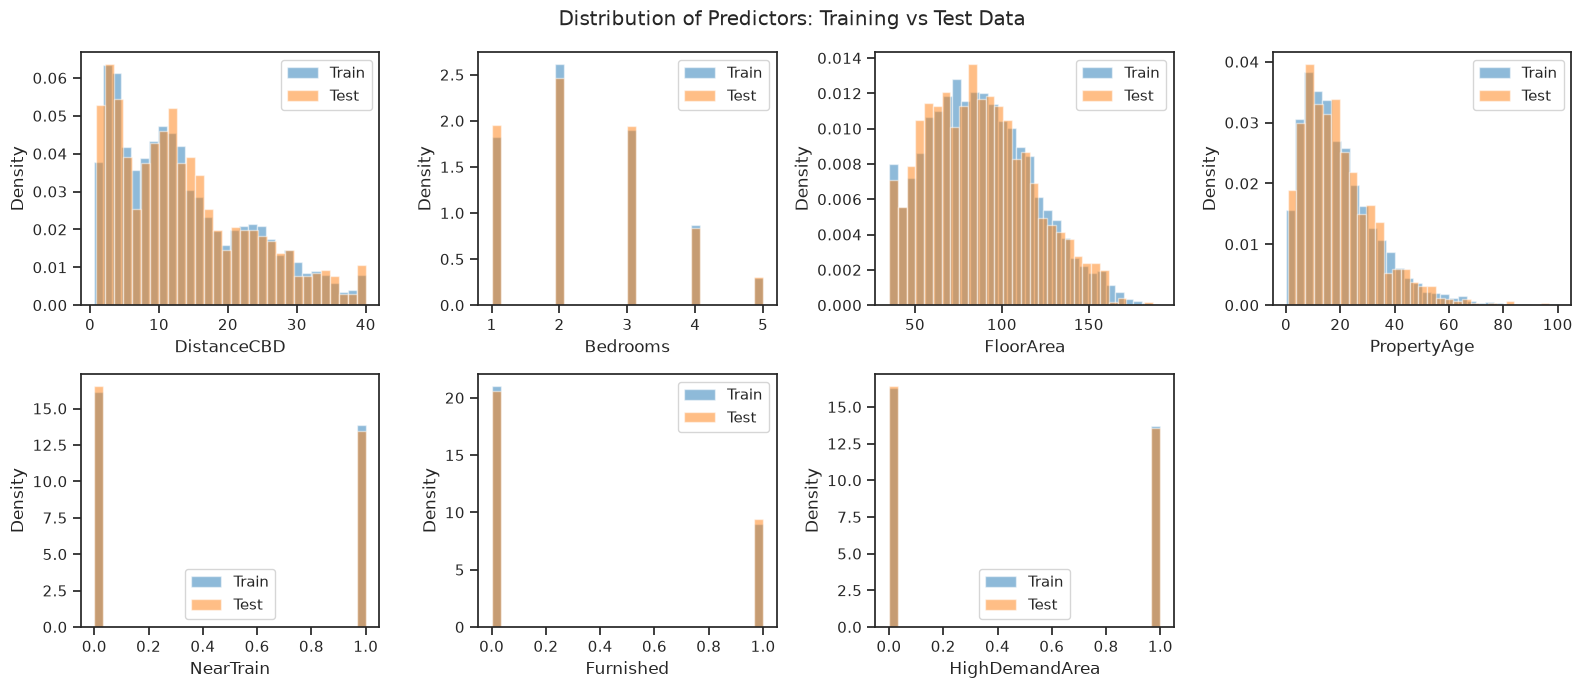

In [7]:
fig, ax = plt.subplots(2, 4, figsize=(16, 7))
ax = ax.flatten()

for i, var in enumerate(predictors):
    ax[i].hist(train[var], bins=30, density=True, alpha = 0.5, label = "Train")
    ax[i].hist(test[var], bins=30, density=True, alpha = 0.5, label = "Test")
    ax[i].set_xlabel(var)
    ax[i].set_ylabel("Density")
    ax[i].legend()

ax[7].axis('off') # only 7 predictors, so the last panel is empty
fig.suptitle("Distribution of Predictors: Training vs Test Data")
plt.tight_layout()
plt.savefig("figures/fig01_train_vs_test.png")
plt.show()

### 2.5 Boundary values and the tail of `PropertyAge`

The summary statistics show that `DistanceCBD` has a maximum of exactly 40 and `FloorArea` a minimum of exactly 35.
If many observations sit exactly at these values, they are likely **capped** (values beyond the limit were recorded as the limit).
We also look at the long right tail of `PropertyAge`.

In [8]:
n_dist_40 = (train['DistanceCBD'] == 40).sum()
next_largest = train.loc[train['DistanceCBD'] < 40, 'DistanceCBD'].max()
print('DistanceCBD = 40: {} training rows, {} test rows (next largest value: {})'.format(
    n_dist_40, (test['DistanceCBD'] == 40).sum(), next_largest))

n_area_35 = (train['FloorArea'] == 35).sum()
next_smallest = train.loc[train['FloorArea'] > 35, 'FloorArea'].min()
print('FloorArea = 35:   {} training rows, {} test rows (next smallest value: {})'.format(
    n_area_35, (test['FloorArea'] == 35).sum(), next_smallest))

DistanceCBD = 40: 43 training rows, 12 test rows (next largest value: 39.65)
FloorArea = 35:   106 training rows, 24 test rows (next smallest value: 35.2)


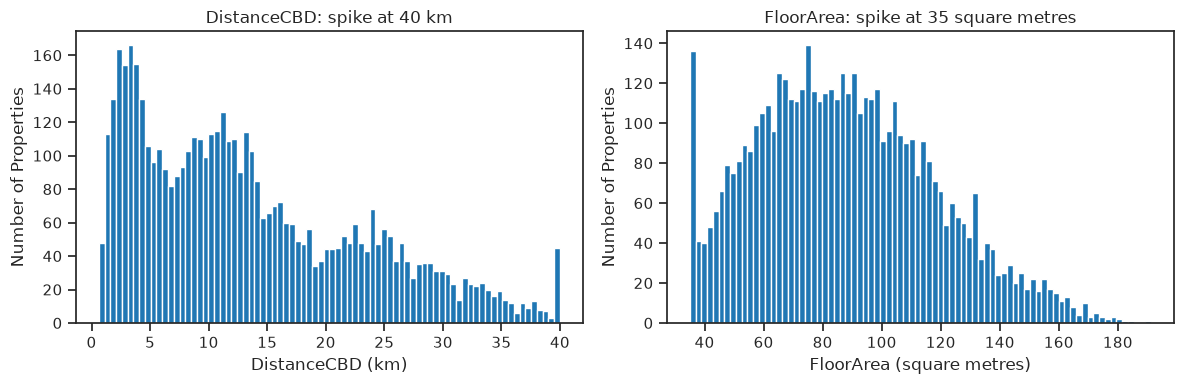

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(train['DistanceCBD'], bins=80)
ax[0].set_xlabel("DistanceCBD (km)")
ax[0].set_ylabel("Number of Properties")
ax[0].set_title("DistanceCBD: spike at 40 km")

ax[1].hist(train['FloorArea'], bins=80)
ax[1].set_xlabel("FloorArea (square metres)")
ax[1].set_ylabel("Number of Properties")
ax[1].set_title("FloorArea: spike at 35 square metres")

plt.tight_layout()
plt.savefig("figures/fig02_boundary_values.png")
plt.show()

In [10]:
# Upper quantiles and the largest values of PropertyAge
print(train['PropertyAge'].quantile([0.5, 0.9, 0.95, 0.99]).round(4))
print('Properties older than 60 years: {}'.format((train['PropertyAge'] > 60).sum()))
print('Ten largest ages: {}'.format(train['PropertyAge'].nlargest(10).tolist()))
print('Largest age in test data: {}'.format(test['PropertyAge'].max()))

0.50    16.400
0.90    38.210
0.95    46.900
0.99    66.501
Name: PropertyAge, dtype: float64
Properties older than 60 years: 94
Ten largest ages: [100.0, 100.0, 99.9, 97.6, 96.0, 94.6, 91.5, 88.3, 88.2, 87.5]
Largest age in test data: 96.9


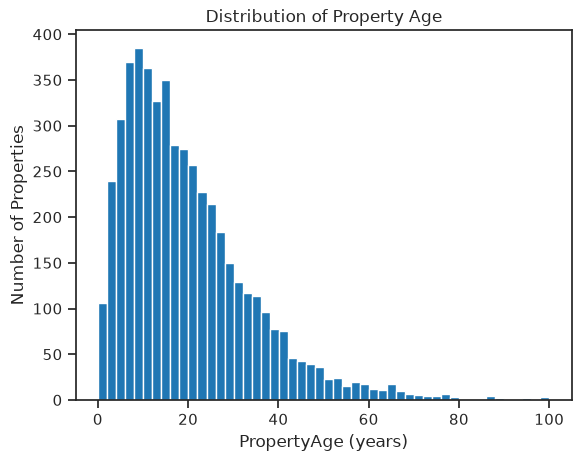

In [11]:
fig = plt.figure()

plt.hist(train['PropertyAge'], bins=50)
plt.xlabel("PropertyAge (years)")
plt.ylabel("Number of Properties")
plt.title("Distribution of Property Age")
plt.savefig("figures/fig03_property_age.png")

plt.show()

### 2.6 Distribution of the response

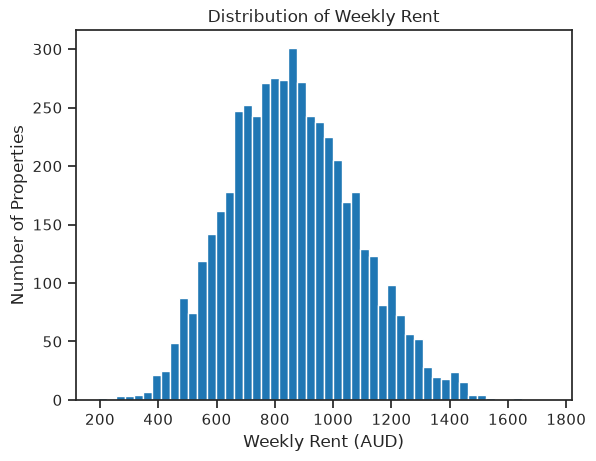

Mean: 860.6811, median: 849.0900, std: 215.4138, skewness: 0.2660


In [12]:
fig = plt.figure()

plt.hist(train[response], bins=50)
plt.xlabel("Weekly Rent (AUD)")
plt.ylabel("Number of Properties")
plt.title("Distribution of Weekly Rent")
plt.savefig("figures/fig04_rent_histogram.png")

plt.show()

print('Mean: {0:.4f}, median: {1:.4f}, std: {2:.4f}, skewness: {3:.4f}'.format(
    train[response].mean(), train[response].median(), train[response].std(), train[response].skew()))

### 2.7 Weekly rent vs continuous predictors

For each continuous predictor we plot the data together with two fitted curves: a straight line
(simple linear regression) and a quadratic curve (polynomial regression of degree 2).
If the quadratic curve departs clearly from the straight line, the relationship is non-linear.

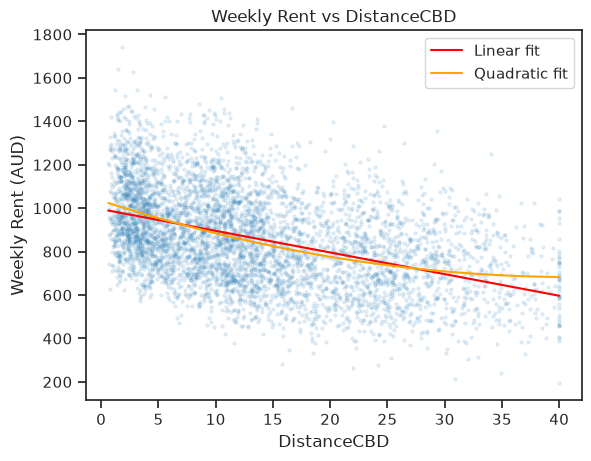

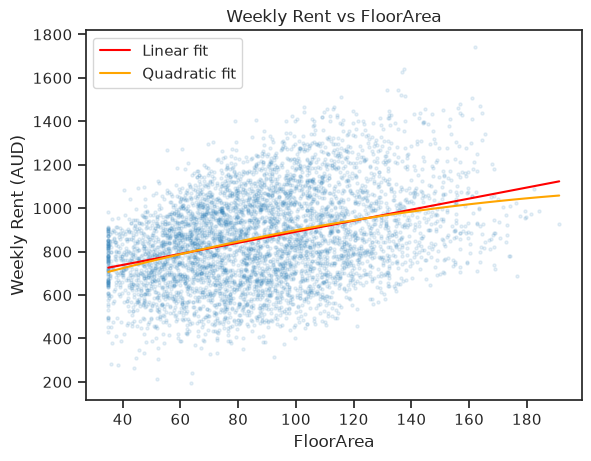

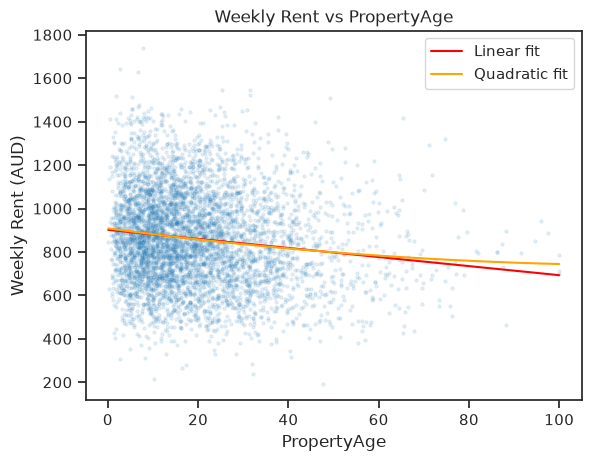

In [13]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

for i, var in enumerate(continuous):
    x = train[[var]].values
    y = train[response]
    x_points = np.linspace(x.min(), x.max(), 100).reshape(-1, 1) # evenly spaced values to draw the curves

    # Straight line
    lin_reg = LinearRegression().fit(x, y)
    # Quadratic curve
    poly_transformer = PolynomialFeatures(2)
    poly_reg = LinearRegression().fit(poly_transformer.fit_transform(x), y)

    fig = plt.figure()
    plt.scatter(x, y, alpha = 0.1, s = 5)
    plt.plot(x_points, lin_reg.predict(x_points), color = "red", label = "Linear fit")
    plt.plot(x_points, poly_reg.predict(poly_transformer.transform(x_points)), color = "orange", label = "Quadratic fit")
    plt.xlabel(var)
    plt.ylabel("Weekly Rent (AUD)")
    plt.title("Weekly Rent vs " + var)
    plt.legend()
    plt.savefig("figures/fig05_rent_vs_{}.png".format(var))
    plt.show()

### 2.8 Weekly rent by `Bedrooms` and by the binary predictors

Box plots compare the distribution of weekly rent across the groups of each discrete predictor.
The table below the plot gives the group means.

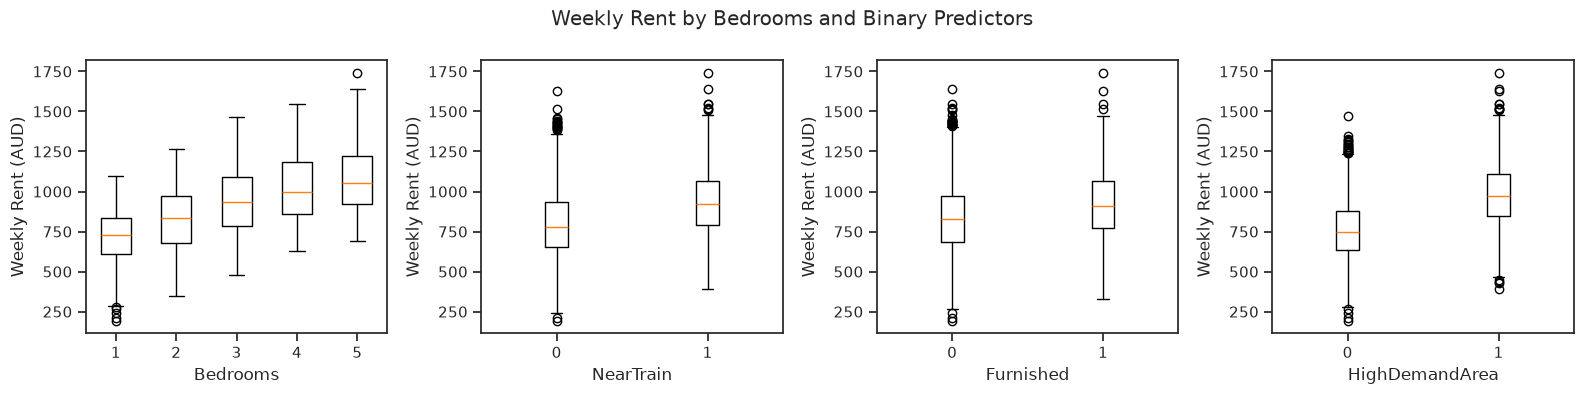

In [14]:
# NOTE: not from tutorial — reason: box plots are requested for this EDA; the tutorials compare groups with overlaid histograms (W1)
group_vars = ['Bedrooms'] + binary

fig, ax = plt.subplots(1, 4, figsize=(16, 4))

for i, var in enumerate(group_vars):
    levels = sorted(train[var].unique())
    ax[i].boxplot([train.loc[train[var] == level, response] for level in levels])
    ax[i].set_xticklabels(levels)
    ax[i].set_xlabel(var)
    ax[i].set_ylabel("Weekly Rent (AUD)")

fig.suptitle("Weekly Rent by Bedrooms and Binary Predictors")
plt.tight_layout()
plt.savefig("figures/fig06_rent_boxplots.png")
plt.show()

In [15]:
for var in group_vars:
    print(train.groupby(var)[response].agg(['count', 'mean']).round(4), '\n')

          count       mean
Bedrooms                  
1          1213   717.9369
2          1741   823.7616
3          1264   938.8978
4           583  1020.8464
5           199  1087.7315 

           count      mean
NearTrain                 
0           2690  797.2066
1           2310  934.5973 

           count      mean
Furnished                 
0           3501  835.9160
1           1499  918.5214 

                count      mean
HighDemandArea                 
0                2719  759.2359
1                2281  981.6058 



### 2.9 Correlations

The correlation matrix shows the linear association between each pair of variables.
It is used both to rank predictors by their linear association with rent and to detect multicollinearity among predictors.
Correlations only capture linear relationships, so they are read together with the plots above.

In [16]:
correlations = train.corr()
correlations.round(4)

,WeeklyRent,DistanceCBD,Bedrooms,FloorArea,PropertyAge,NearTrain,Furnished,HighDemandArea
WeeklyRent,1.0000,-0.4421,0.5062,0.3567,-0.1375,0.3180,0.1757,0.5142
DistanceCBD,-0.4421,1.0000,0.3319,0.5286,0.0163,-0.1780,-0.1300,-0.3727
Bedrooms,0.5062,0.3319,1.0000,0.8821,-0.0009,-0.0589,-0.1297,-0.1276
FloorArea,0.3567,0.5286,0.8821,1.0000,-0.0079,-0.0882,-0.1339,-0.1947
PropertyAge,-0.1375,0.0163,-0.0009,-0.0079,1.0000,0.0186,-0.0598,-0.0104
NearTrain,0.3180,-0.1780,-0.0589,-0.0882,0.0186,1.0000,0.0039,0.2385
Furnished,0.1757,-0.1300,-0.1297,-0.1339,-0.0598,0.0039,1.0000,0.0273
HighDemandArea,0.5142,-0.3727,-0.1276,-0.1947,-0.0104,0.2385,0.0273,1.0000


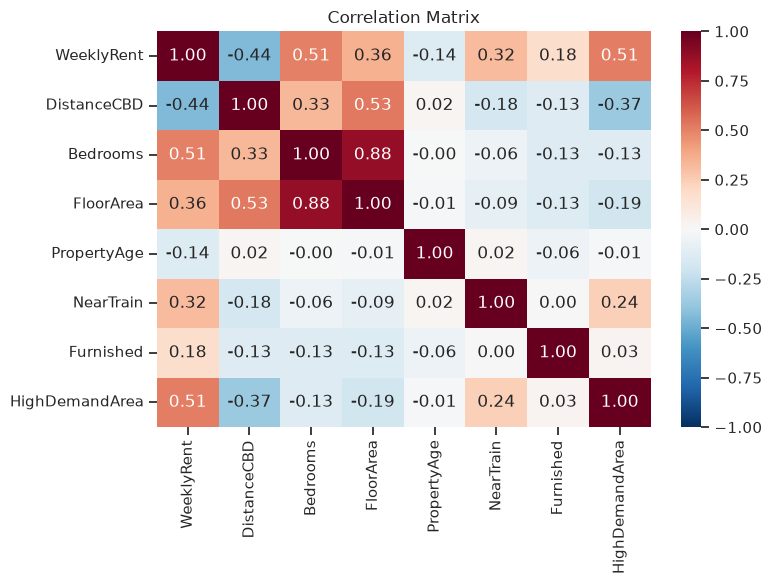

In [17]:
# NOTE: not from tutorial — reason: a heatmap displays the correlation table above more clearly (seaborn is used in W2)
fig = plt.figure(figsize=(8, 6))

sns.heatmap(correlations, annot = True, fmt = ".2f", cmap = "RdBu_r", vmin = -1, vmax = 1)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig("figures/fig07_correlation_heatmap.png")

plt.show()

### 2.10 Interaction exploration

An interaction means that the effect of one predictor on rent depends on the value of another predictor.
We first look at plots: for each group of a binary variable, we fit a separate straight line.
Lines with clearly different slopes suggest an interaction.

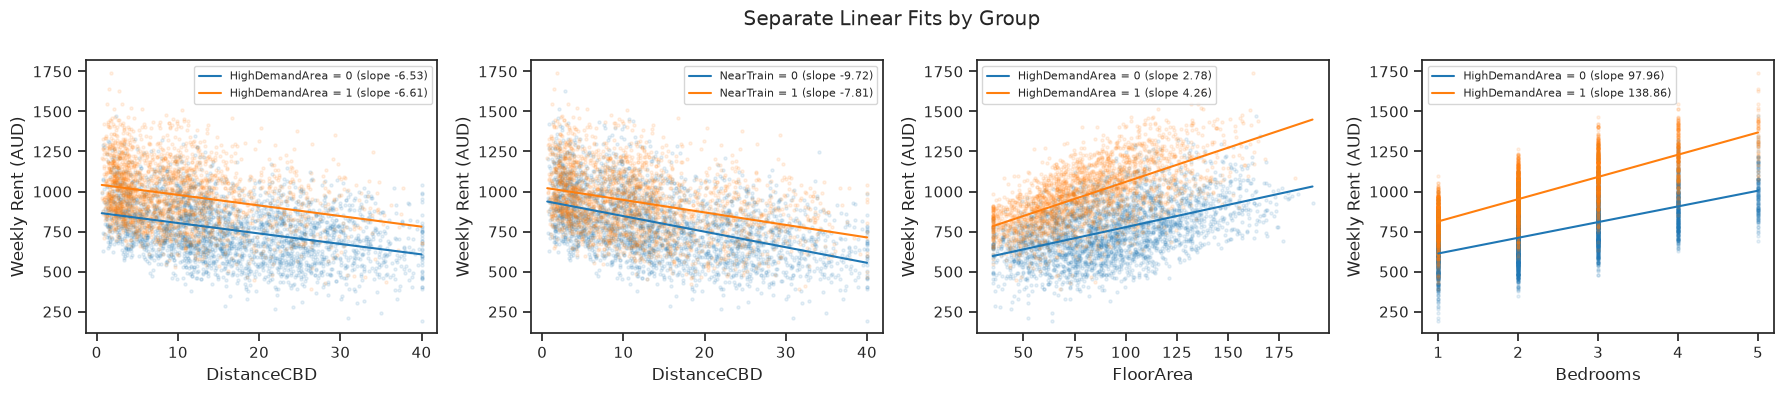

In [18]:
pairs = [('DistanceCBD', 'HighDemandArea'), ('DistanceCBD', 'NearTrain'),
         ('FloorArea', 'HighDemandArea'), ('Bedrooms', 'HighDemandArea')]

fig, ax = plt.subplots(1, 4, figsize=(18, 4))

for i, (var, group) in enumerate(pairs):
    for level, color in zip([0, 1], ["#1F77B4", "#FF7F0E"]):
        subset = train[train[group] == level]
        x_with_intercept = sm.add_constant(subset[[var]], prepend=True)
        est = sm.OLS(subset[response], x_with_intercept).fit()
        x_points = np.linspace(train[var].min(), train[var].max(), 100)

        ax[i].scatter(subset[var], subset[response], alpha = 0.1, s = 5, color = color)
        ax[i].plot(x_points, est.params.iloc[0] + est.params.iloc[1] * x_points, color = color,
                   label = "{} = {} (slope {:.2f})".format(group, level, est.params.iloc[1]))
    ax[i].set_xlabel(var)
    ax[i].set_ylabel("Weekly Rent (AUD)")
    ax[i].legend(fontsize = 8)

fig.suptitle("Separate Linear Fits by Group")
plt.tight_layout()
plt.savefig("figures/fig08_interaction_plots.png")
plt.show()

Slopes estimated separately within each group can be confounded by the other predictors (for example,
high-demand areas are closer to the CBD). To assess each candidate term while holding the other predictors fixed,
we start from the OLS model with all seven predictors and add **one** candidate term at a time
(each pairwise interaction, and the square of each non-binary predictor).
For each term we record the p-value and how much the AIC falls relative to the base model (larger = more useful).
This is only a screening step; the final choice of terms is made with cross-validation in the modelling section.

In [19]:
import itertools

x_with_intercept = sm.add_constant(train[predictors], prepend=True)
base = sm.OLS(train[response], x_with_intercept).fit()

screening = []
# Pairwise interactions
for var1, var2 in itertools.combinations(predictors, 2):
    x = train[predictors].copy()
    x['new_term'] = x[var1] * x[var2]
    est = sm.OLS(train[response], sm.add_constant(x, prepend=True)).fit()
    screening.append({'Term': var1 + ' x ' + var2, 'AIC drop': base.aic - est.aic, 'p-value': est.pvalues['new_term']})
# Squared terms (not for 0/1 variables, since x^2 = x)
for var in continuous + ['Bedrooms']:
    x = train[predictors].copy()
    x['new_term'] = x[var] ** 2
    est = sm.OLS(train[response], sm.add_constant(x, prepend=True)).fit()
    screening.append({'Term': var + '^2', 'AIC drop': base.aic - est.aic, 'p-value': est.pvalues['new_term']})

screening = pd.DataFrame(screening).sort_values('AIC drop', ascending = False).set_index('Term')
screening.round(4)

,AIC drop,p-value
Term,,
DistanceCBD^2,787.1584,0.0000
Bedrooms x HighDemandArea,499.6712,0.0000
FloorArea x HighDemandArea,318.7484,0.0000
Bedrooms x FloorArea,302.7626,0.0000
FloorArea^2,262.0211,0.0000
Bedrooms^2,217.4390,0.0000
Bedrooms x Furnished,154.8575,0.0000
FloorArea x NearTrain,146.9916,0.0000
DistanceCBD x NearTrain,125.1242,0.0000


### 2.11 Residuals of a baseline OLS model

We fit OLS with all seven predictors (linear terms only) and plot its residuals.
Systematic patterns in the residuals show what the linear model is missing.

In [20]:
x_with_intercept = sm.add_constant(train[predictors], prepend=True)
ols = sm.OLS(train[response], x_with_intercept)
est = ols.fit()
print(est.summary())

                            OLS Regression Results                            
Dep. Variable:             WeeklyRent   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                     9345.
Date:                Sat, 26 Sep 2026   Prob (F-statistic):               0.00
Time:                        12:54:42   Log-Likelihood:                -27341.
No. Observations:                5000   AIC:                         5.470e+04
Df Residuals:                    4992   BIC:                         5.475e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const            481.9479      3.335    144.

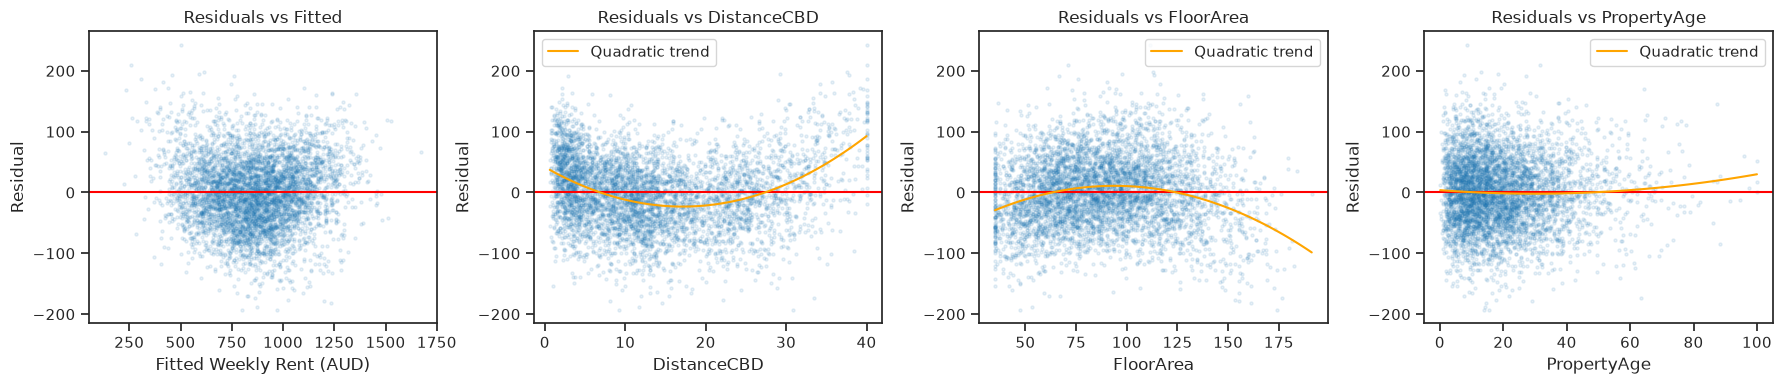

In [21]:
residuals = est.resid
fitted = est.fittedvalues

fig, ax = plt.subplots(1, 4, figsize=(18, 4))

ax[0].scatter(fitted, residuals, alpha = 0.1, s = 5)
ax[0].axhline(0, color = "red")
ax[0].set_xlabel("Fitted Weekly Rent (AUD)")
ax[0].set_ylabel("Residual")
ax[0].set_title("Residuals vs Fitted")

for i, var in enumerate(continuous):
    x = train[[var]].values
    x_points = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)
    poly_transformer = PolynomialFeatures(2)
    poly_reg = LinearRegression().fit(poly_transformer.fit_transform(x), residuals)

    ax[i + 1].scatter(x, residuals, alpha = 0.1, s = 5)
    ax[i + 1].axhline(0, color = "red")
    ax[i + 1].plot(x_points, poly_reg.predict(poly_transformer.transform(x_points)), color = "orange", label = "Quadratic trend")
    ax[i + 1].set_xlabel(var)
    ax[i + 1].set_ylabel("Residual")
    ax[i + 1].set_title("Residuals vs " + var)
    ax[i + 1].legend()

plt.tight_layout()
plt.savefig("figures/fig09_baseline_ols_residuals.png")
plt.show()

### 2.12 Summary of EDA findings

1. **Data quality.** 5000 training and 1000 test rows, all numeric, no missing values or duplicates.
   The binary predictors are already 0/1 dummies.
2. **Train vs test.** Test covariates have very similar means, spreads and ranges to the training covariates,
   so the model will not need to extrapolate.
3. **Boundary values.** `DistanceCBD` is capped at 40 km (43 training rows; next value 39.65) and `FloorArea` is floored
   at 35 m² (106 rows; next value 35.2). Once a quadratic distance term is included, the residuals at the caps are not
   different from those of neighbouring values, so no separate indicator is needed.
   `PropertyAge` has a long right tail (99th percentile 66.5 years, maximum 100), but these points are plausible and are kept.
4. **Response.** `WeeklyRent` is roughly symmetric (skewness 0.27), so no transformation of the response is needed.
5. **Non-linearity.** Rent falls with distance but flattens out far from the CBD (U-shaped OLS residuals),
   and rises with floor area at a decreasing rate (inverted-U residuals). `PropertyAge` is close to linear.
6. **Group differences.** High-demand areas (+222 AUD on average), proximity to a train station (+137) and
   furnishing (+83) are all associated with higher rent; rent rises steadily with the number of bedrooms.
7. **Multicollinearity.** `Bedrooms` and `FloorArea` are highly correlated (0.88); the other predictor
   correlations are moderate (at most 0.53 in absolute value).
8. **Interactions.** Holding the other predictors fixed, the strongest candidate terms are `DistanceCBD^2`,
   `Bedrooms x HighDemandArea`, `FloorArea x HighDemandArea`, `Bedrooms x FloorArea` and `FloorArea^2`.
   Terms involving `PropertyAge` add almost nothing.
9. **Baseline OLS.** The linear model already explains most of the variation (R² = 0.929), but the residual patterns
   confirm that non-linear and interaction terms are needed.